In [25]:
# _rd_00.py 
# SDL, SRL, simple case 
# 상관관계, 상관계수, 공분산, 산포도. 그룹, 히스토그램 등 회귀분석 전 설명.

# 이 코드 - 산포도와 중심점 표시. 
# raw data - x: 키, y: 체중, n = 3111 
# mean function in regression. 작업예정... 

import os
import numpy as np                          # numpy 라이브러리 전체. 
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네. 
import scipy as sci 
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈. 필요한 통계 모듈만.
import statsmodels.api as sm                # 방대한 모델이라 개발자들이 많이 쓰는 모델 묶음.
from statsmodels.tsa import stattools       # time series analysis 
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭. 소문자 못읽어.
import matplotlib.pyplot as plt


In [26]:

# 데이터 파일 읽기. github.com
dat_url = 'https://github.com/bahn28/gamja/blob/main/cs_nns_hgt_wgt.xlsx?raw=true'
df_dat = pd.read_excel(dat_url) 
df_dat.head(7) 


,x,y
0,174.262367,70.149796
1,166.350641,60.169389
2,158.381596,63.394676
3,163.472285,46.948571
4,157.954485,49.428887
5,172.040252,65.522781
6,195.490612,88.556610


In [27]:
# 1. 데이터 준비. 읽기. 생성. 
n_obs = len(df_dat) 
hgt = df_dat['x'].to_numpy()
wgt = df_dat['y'].to_numpy()
#    gndr = (gndrlit == 'Male').astype(int)   # astype(int)으로 NumPy 배열 전환, 1/0  


# 2. 자료 검토, 요약, 그래프 생성.
# 2a. 자료 검토, 기초 통계량
summ = df_dat.agg(
            ["count", "mean", "std", "min", "median", "max"]
            ) # 일부 변수, 일부 통계량 
# print(summ)
summ.head(7)


,x,y
count,3111.000000,3111.000000
mean,167.076163,63.463587
std,8.599366,12.642302
min,138.146769,20.077826
median,167.040445,63.680696
max,198.211156,106.538459


In [28]:
# def save_chart(fname, outdir, fig=None, dpi=300, bbox_inches='tight', transparent=False):
#     if fig is None:
#         fig = plt.gcf()
#     os.makedirs(outdir, exist_ok=True)
#     name, ext = os.path.splitext(fname)  # fname(파일)을 이름과 익스텐션으로 분리.
#     ext = ext or '.png'
#     path = os.path.join(outdir, name + ext)  # outdir에 fname을 짤라서 그림 이름으로 지정하네? 
#     fig.savefig(path, dpi=dpi, bbox_inches=bbox_inches, transparent=transparent)
#     return path


In [29]:
# 평균점, 분산, 상관계수 
mean_x = hgt.mean()
mean_y = wgt.mean() 
sig_x = hgt.std(ddof=1)
sig_y = wgt.std(ddof=1)
r_xy = np.corrcoef(hgt, wgt)[0,1]  # 상관계수 행렬의 한 원소.
c_xy = np.cov(hgt, wgt)[0, 1]      # 공분산

# SDL, SRL, 준비
b_sdl = (sig_y/sig_x) 
a_sdl = mean_y - b_sdl * mean_x 

b_srl = r_xy*(sig_y/sig_x) 
a_srl = mean_y - b_srl * mean_x 

x_span = np.linspace(130, 200)
y_sdl = a_sdl + b_sdl * x_span 
y_srl = a_srl + b_srl * x_span 

# 키 그룹별 자료 준비.
dat_1 = df_dat[(df_dat['x'] > 155.99) & (df_dat['x'] < 158)] # 밴드 1. 작은 키 소그룹
x_g1 = dat_1['x'] 
y_g1 = dat_1['y'] 

dat_2 = df_dat[(df_dat['x'] > 165.99) & (df_dat['x'] < 168)] # 밴드 2. 평균 키 소그룹
x_g2 = dat_2['x'] 
y_g2 = dat_2['y'] 

dat_3 = df_dat[(df_dat['x'] > 175.99) & (df_dat['x'] < 178)] # 밴드 3. 큰 키 소그룹
x_g3 = dat_3['x'] 
y_g3 = dat_3['y'] 


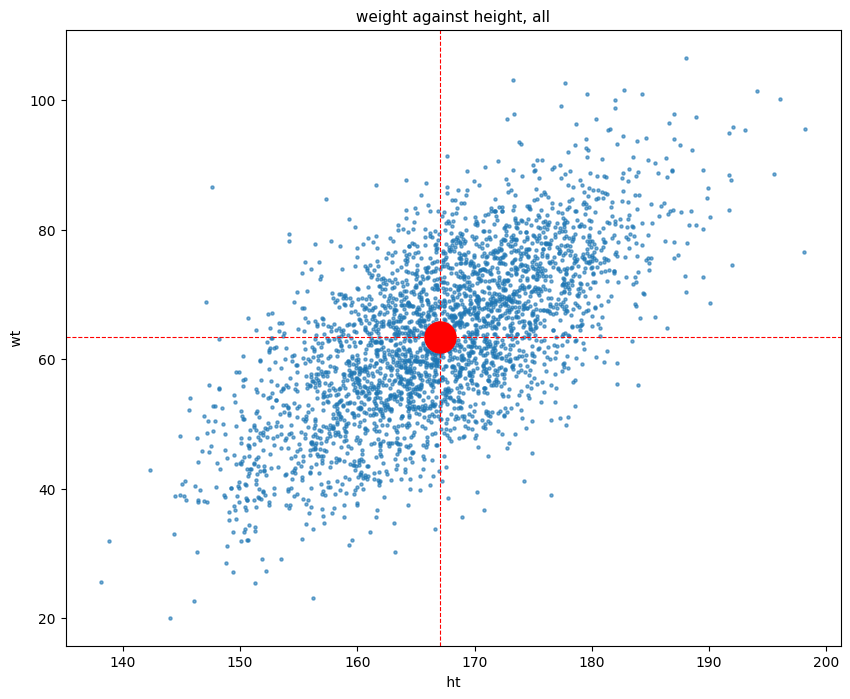

In [30]:
# 자료 검토, 시각화 확인.
# 산포도 ( x, y ), 평균점   
fig = plt.figure(figsize=(10, 8))  # 이건 객체. 
plt.scatter(hgt, wgt, s=5, alpha=0.6 ) #facecolor='none', edgecolor='black')
plt.scatter(mean_x, mean_y, s=500, c='red', marker='o')
#plt.plot(x_span, y_sdl, color='black')

plt.axvline(mean_x, color='red', linestyle='--', lw=0.8)
plt.axhline(mean_y, color='red', linestyle='--', lw=0.8)

plt.title(" weight against height, all ", fontsize=11)
plt.xlabel(" ht ")
plt.ylabel(" wt ")

plt.show()


## 중심을 지나는 직선, SDL/SRL

중심을 지나면서 기울기는 표준편차의 비인 직선
\begin{align}
 y - \bar y & = b ( x- \bar x)  \\ 
 b & = {\sigma_y \over \sigma_x} 
\end{align}
풀어 쓰면 
\begin{align}
 y & = a + b x \\
 b & = {\sigma_y \over \sigma_x} \\
 a & = \bar y - b \bar x  \\ 
\end{align}

## 배경 연습.


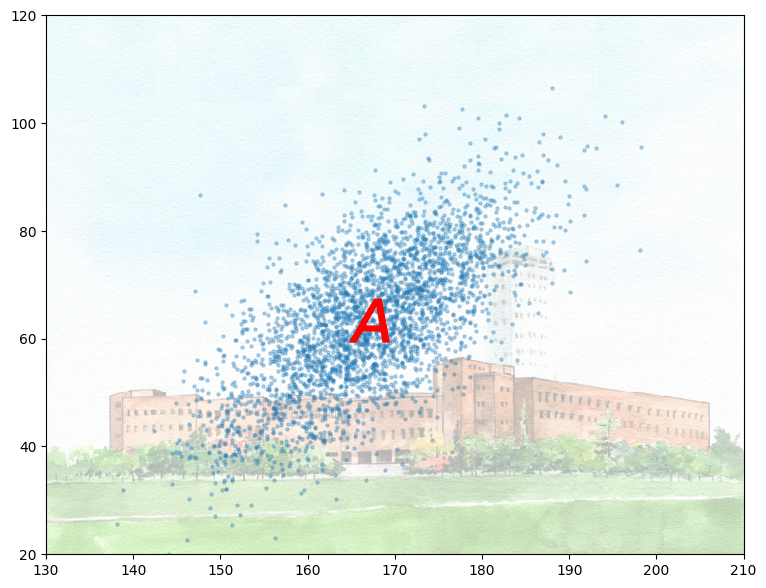

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# 1. 깃허브 Raw 이미지 URL 설정
jpg_url = 'https://github.com/bahn28/gamja/blob/main/econlab.jpg?raw=true'
# 2. 웹에서 이미지 다운로드 후 PIL로 읽기
response = requests.get(jpg_url)
bg_img = Image.open(BytesIO(response.content))

# 1. 배경으로 쓸 이미지 파일 읽기
# (프로젝트 폴더 안에 bg_photo.jpg가 있다고 가정합니다)
#bg_img = plt.imread("econlab.jpg")
#fig = plt.figsize=(10, 10)
#fig = plt.figure(figsize=(10, 8))  # 이건 객체. 
fig, ax = plt.subplots(figsize=(9, 7))

# 2. 배경 이미지 깔기 (핵심 파트 ⭐)
ax.imshow(bg_img, 
          extent=[130, 210, 20, 120],  # [X축최소, X축최대, Y축최소, Y축최대] 내 데이터 범위와 맞추기! 
          aspect='auto',           # imshow는 기본 옵션이 'equal'임. 그림 비율대로 고정한다는 것...
          alpha=0.3,               # 이미지가 너무 진하면 선이 안 보이므로 투명도 조절 (0~1)
          zorder=0)                # zorder를 0으로 둬야 맨 아래(배경)에 깔립니다.

# 3. 그 위에 원래 그리려던 plot 그리기
# (zorder를 이미지보다 높은 1 이상으로 주면 선이 이미지 위로 올라옵니다)
plt.scatter(hgt, wgt, s=5, alpha=0.3 ) #facecolor='none', edgecolor='black')
plt.scatter(mean_x, mean_y, s=950, c='red', marker="$ A $")
#plt.plot(x_span, y_sdl, color='black')

# ax.set_aspect('equal')  # imshow에서 기본 옵션임. 
# 4. 축 범위 고정 (이미지가 축 바깥으로 밀리는 것 방지)
ax.set_xlim(130, 210)
ax.set_ylim(20, 120)

plt.show()
